In [12]:
# ── BEFORE PREPROCESSING - RAW DATA ──────────────────────
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('../data/application_train.csv')

print("="*50)
print("RAW DATA - BEFORE PREPROCESSING")
print("="*50)
print(f"Shape: {df_raw.shape}")
print(f"\nData Types Summary:")
print(df_raw.dtypes.value_counts())
print(f"\nSample Raw Data:")
df_raw[['AMT_INCOME_TOTAL','AMT_CREDIT',
        'DAYS_BIRTH','DAYS_EMPLOYED',
        'CODE_GENDER','TARGET']].head()

RAW DATA - BEFORE PREPROCESSING
Shape: (307511, 122)

Data Types Summary:
float64    65
int64      41
object     16
Name: count, dtype: int64

Sample Raw Data:


,AMT_INCOME_TOTAL,AMT_CREDIT,DAYS_BIRTH,DAYS_EMPLOYED,CODE_GENDER,TARGET
0,202500.0,406597.5,-9461,-637,M,1
1,270000.0,1293502.5,-16765,-1188,F,0
2,67500.0,135000.0,-19046,-225,M,0
3,135000.0,312682.5,-19005,-3039,F,0
4,121500.0,513000.0,-19932,-3038,M,0


In [14]:
# ── DATA QUALITY PROBLEMS IN RAW DATA ────────────────────
print("="*50)
print("DATA QUALITY ISSUES FOUND IN RAW DATA")
print("="*50)

# Problem 1
total_missing = df_raw.isnull().sum().sum()
cols_missing = (df_raw.isnull().sum() > 0).sum()
print(f"\n Problem 1: Missing Values")
print(f"   Total missing cells : {total_missing:,}")
print(f"   Columns affected    : {cols_missing}")

# Problem 2
anomaly = (df_raw['DAYS_EMPLOYED'] == 365243).sum()
print(f"\n Problem 2: DAYS_EMPLOYED Anomaly (365243 = unemployed)")
print(f"   Affected records : {anomaly:,} ({anomaly/len(df_raw)*100:.1f}%)")

# Problem 3
cat_cols = df_raw.select_dtypes(include='object').columns
print(f"\n Problem 3: Categorical Columns (not ML ready)")
print(f"   Count    : {len(cat_cols)}")
print(f"   Examples : {list(cat_cols[:4])}")

# Problem 4
print(f"\n Problem 4: No Derived Features")
print(f"   No AGE_YEARS, CREDIT_INCOME_RATIO etc.")
print(f"   Raw feature count: {df_raw.shape[1]}")

DATA QUALITY ISSUES FOUND IN RAW DATA

 Problem 1: Missing Values
   Total missing cells : 9,152,465
   Columns affected    : 67

 Problem 2: DAYS_EMPLOYED Anomaly (365243 = unemployed)
   Affected records : 55,374 (18.0%)

 Problem 3: Categorical Columns (not ML ready)
   Count    : 16
   Examples : ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

 Problem 4: No Derived Features
   No AGE_YEARS, CREDIT_INCOME_RATIO etc.
   Raw feature count: 122


In [16]:
# ── AFTER PREPROCESSING ──────────────────────────────────
from src.data.preprocessor import preprocess

print("="*50)
print("DATA AFTER PREPROCESSING")
print("="*50)

df_processed, target, encoders = preprocess(df_raw.copy())

print(f"\n Fix 1: Missing Values")
print(f"   Before : {df_raw.isnull().sum().sum():,}")
print(f"   After  : {df_processed.isnull().sum().sum()}")

print(f"\n Fix 2: DAYS_EMPLOYED Anomaly Fixed")
anomaly_after = (df_processed['DAYS_EMPLOYED'] == 365243).sum()
print(f"   Before : {anomaly:,} anomalous records")
print(f"   After  : {anomaly_after}")

print(f"\n Fix 3: Categorical Columns Encoded")
cat_after = df_processed.select_dtypes(include='object').columns
print(f"   Before : {len(cat_cols)} text columns")
print(f"   After  : {len(cat_after)} text columns")

print(f"\n Fix 4: New Features Engineered")
new_feats = ['CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO',
             'AGE_YEARS','EMPLOYMENT_YEARS',
             'EMPLOYMENT_AGE_RATIO','CREDIT_TERM','INCOME_PER_PERSON']
for f in new_feats:
    if f in df_processed.columns:
        print(f"    {f}")

print(f"\n FINAL SUMMARY:")
print(f"   Features : {df_raw.shape[1]} → {df_processed.shape[1]}")
print(f"   Missing  : {df_raw.isnull().sum().sum():,} → 0")
print(f"   ML Ready : Yes")

DATA AFTER PREPROCESSING
Starting preprocessing pipeline...
Fixing data anomalies...
✅ Anomalies fixed
Adding engineered features...
✅ Added 7 engineered features
Handling missing values...
✅ Missing values handled
Encoding categorical columns...
✅ Encoded 16 categorical columns
✅ Encoders saved
✅ Preprocessing complete! Shape: (307511, 127)

 Fix 1: Missing Values
   Before : 9,152,465
   After  : 0

 Fix 2: DAYS_EMPLOYED Anomaly Fixed
   Before : 55,374 anomalous records
   After  : 0

 Fix 3: Categorical Columns Encoded
   Before : 16 text columns
   After  : 0 text columns

 Fix 4: New Features Engineered
    CREDIT_INCOME_RATIO
    ANNUITY_INCOME_RATIO
    AGE_YEARS
    EMPLOYMENT_YEARS
    EMPLOYMENT_AGE_RATIO
    CREDIT_TERM
    INCOME_PER_PERSON

 FINAL SUMMARY:
   Features : 122 → 127
   Missing  : 9,152,465 → 0
   ML Ready : Yes


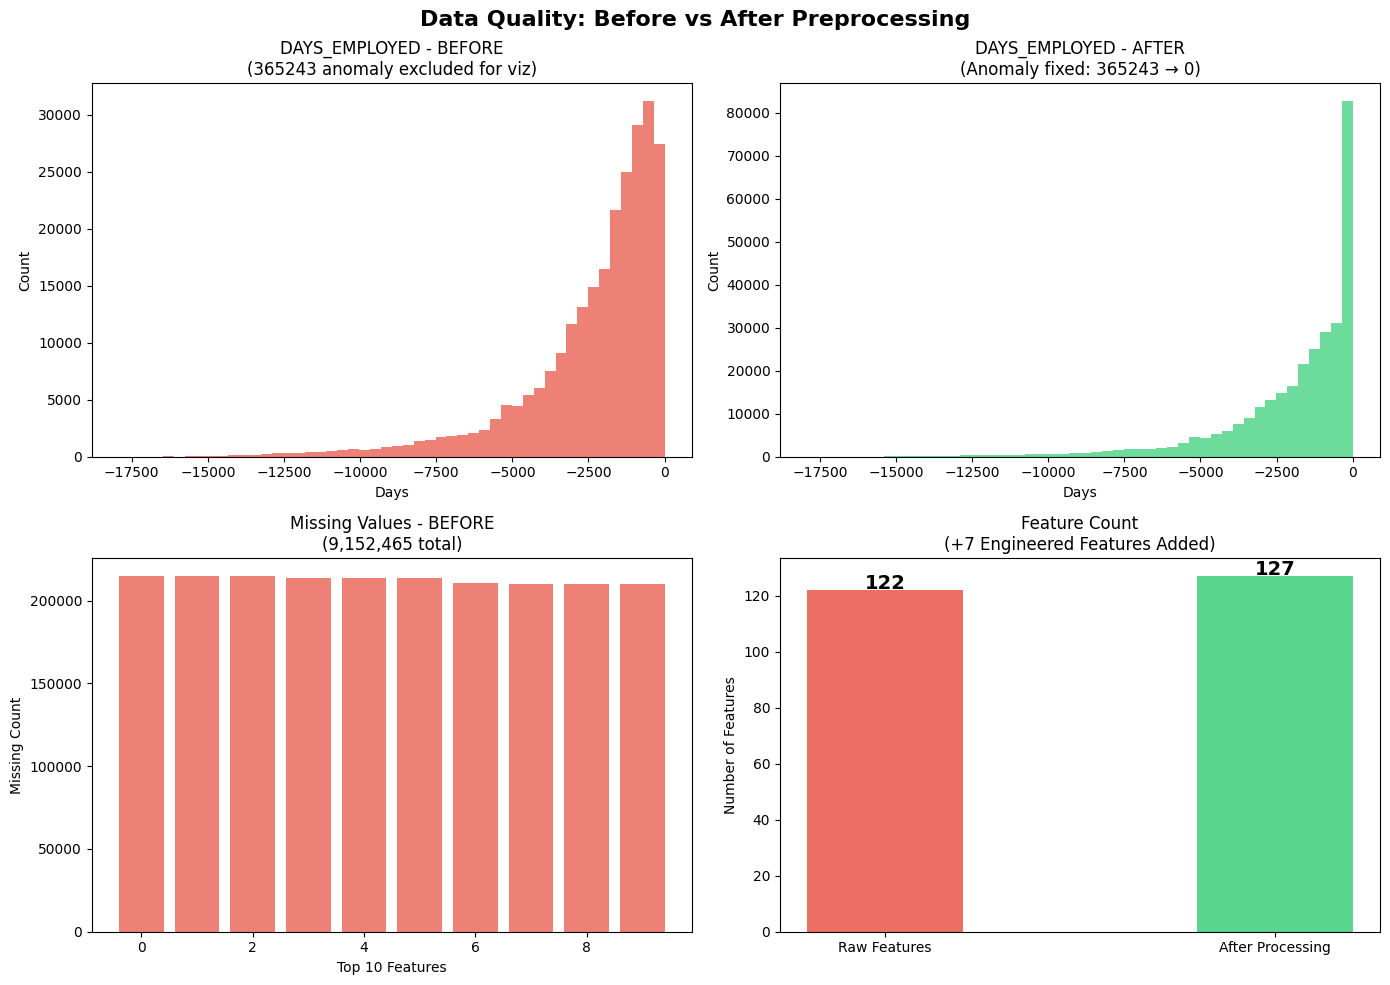

 Before vs After complete!
 df ready for EDA!


In [17]:
# ── BEFORE vs AFTER CHART ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Quality: Before vs After Preprocessing',
             fontsize=16, fontweight='bold')

# Chart 1: DAYS_EMPLOYED BEFORE
axes[0,0].hist(
    df_raw[df_raw['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED'],
    bins=50, color='#e74c3c', alpha=0.7)
axes[0,0].set_title('DAYS_EMPLOYED - BEFORE\n(365243 anomaly excluded for viz)')
axes[0,0].set_xlabel('Days')
axes[0,0].set_ylabel('Count')

# Chart 2: DAYS_EMPLOYED AFTER
axes[0,1].hist(df_processed['DAYS_EMPLOYED'],
               bins=50, color='#2ecc71', alpha=0.7)
axes[0,1].set_title('DAYS_EMPLOYED - AFTER\n(Anomaly fixed: 365243 → 0)')
axes[0,1].set_xlabel('Days')
axes[0,1].set_ylabel('Count')

# Chart 3: Missing values BEFORE
missing_before = df_raw.isnull().sum()
missing_before = missing_before[missing_before > 0]\
    .sort_values(ascending=False).head(10)
axes[1,0].bar(range(len(missing_before)),
              missing_before.values, color='#e74c3c', alpha=0.7)
axes[1,0].set_title(f'Missing Values - BEFORE\n({df_raw.isnull().sum().sum():,} total)')
axes[1,0].set_xlabel('Top 10 Features')
axes[1,0].set_ylabel('Missing Count')

# Chart 4: Feature count comparison
axes[1,1].bar(['Raw Features','After Processing'],
              [df_raw.shape[1], df_processed.shape[1]],
              color=['#e74c3c','#2ecc71'], alpha=0.8, width=0.4)
axes[1,1].set_title('Feature Count\n(+7 Engineered Features Added)')
axes[1,1].set_ylabel('Number of Features')
for i, v in enumerate([df_raw.shape[1], df_processed.shape[1]]):
    axes[1,1].text(i, v+0.5, str(v),
                   ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('../notebooks/images/before_after_preprocessing.png',
            dpi=100, bbox_inches='tight')
plt.show()
print(" Before vs After complete!")

# Set df for rest of EDA
df = pd.read_csv('../data/application_train.csv')
df['AGE_YEARS'] = (-df['DAYS_BIRTH']/365).astype(int)
df['LOAN_INCOME_RATIO'] = df['AMT_CREDIT']/df['AMT_INCOME_TOTAL']
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'].clip(upper=0)/365)
print(" df ready for EDA!")

Total Applications: 307,511
Non-Default: 282,686 (91.9%)
Default:     24,825 (8.1%)


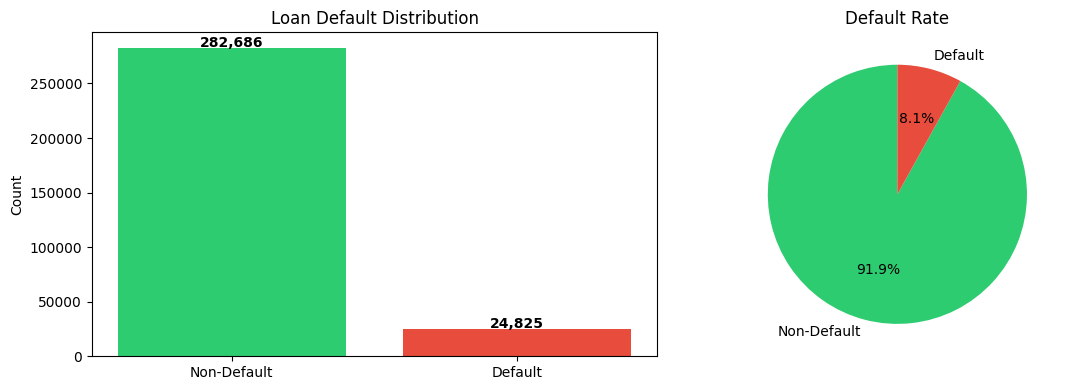

Chart saved!


In [18]:
# Target Distribution
print(f"Total Applications: {len(df):,}")
target_counts = df['TARGET'].value_counts()
print(f"Non-Default: {target_counts[0]:,} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Default:     {target_counts[1]:,} ({target_counts[1]/len(df)*100:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Non-Default', 'Default'], 
            [target_counts[0], target_counts[1]], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Loan Default Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[0], target_counts[1]], 
            labels=['Non-Default', 'Default'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Default Rate')

plt.tight_layout()
plt.savefig('../notebooks/images/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved!")

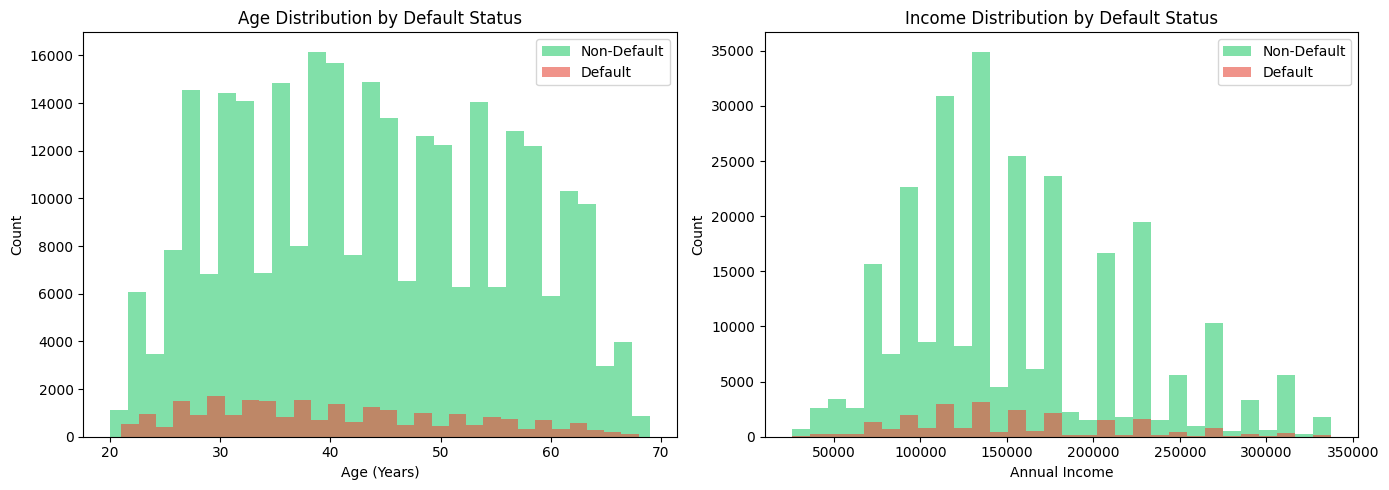

Business Insight 1: Younger applicants default more
Business Insight 2: Lower income applicants default more


In [19]:
# Age and Income Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution (DAYS_BIRTH is negative, convert to years)
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)
axes[0].hist(df[df['TARGET']==0]['AGE_YEARS'], bins=30, alpha=0.6, color='#2ecc71', label='Non-Default')
axes[0].hist(df[df['TARGET']==1]['AGE_YEARS'], bins=30, alpha=0.6, color='#e74c3c', label='Default')
axes[0].set_title('Age Distribution by Default Status')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Income distribution
income_cap = df['AMT_INCOME_TOTAL'].quantile(0.95)
df_income = df[df['AMT_INCOME_TOTAL'] <= income_cap]
axes[1].hist(df_income[df_income['TARGET']==0]['AMT_INCOME_TOTAL'], bins=30, alpha=0.6, color='#2ecc71', label='Non-Default')
axes[1].hist(df_income[df_income['TARGET']==1]['AMT_INCOME_TOTAL'], bins=30, alpha=0.6, color='#e74c3c', label='Default')
axes[1].set_title('Income Distribution by Default Status')
axes[1].set_xlabel('Annual Income')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/age_income_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Business Insight 1: Younger applicants default more")
print("Business Insight 2: Lower income applicants default more")

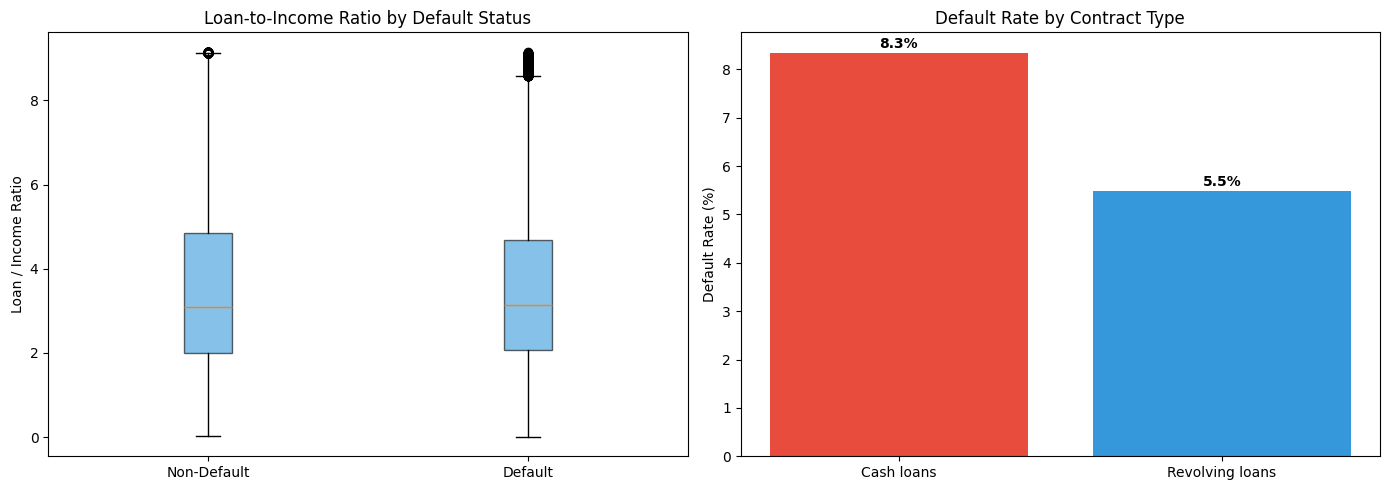

Business Insight 3: Higher loan-to-income ratio = higher default risk
Business Insight 4: Cash loans have higher default rate than revolving loans


In [21]:
# Loan Amount Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan amount vs income ratio
df['LOAN_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
ratio_cap = df['LOAN_INCOME_RATIO'].quantile(0.95)
df_ratio = df[df['LOAN_INCOME_RATIO'] <= ratio_cap]

axes[0].boxplot([
    df_ratio[df_ratio['TARGET']==0]['LOAN_INCOME_RATIO'],
    df_ratio[df_ratio['TARGET']==1]['LOAN_INCOME_RATIO']
], labels=['Non-Default', 'Default'], patch_artist=True,
boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[0].set_title('Loan-to-Income Ratio by Default Status')
axes[0].set_ylabel('Loan / Income Ratio')

# Contract type
contract_default = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean() * 100
axes[1].bar(contract_default.index, contract_default.values, 
            color=['#e74c3c', '#3498db'])
axes[1].set_title('Default Rate by Contract Type')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(contract_default.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/images/loan_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Business Insight 3: Higher loan-to-income ratio = higher default risk")
print("Business Insight 4: Cash loans have higher default rate than revolving loans")

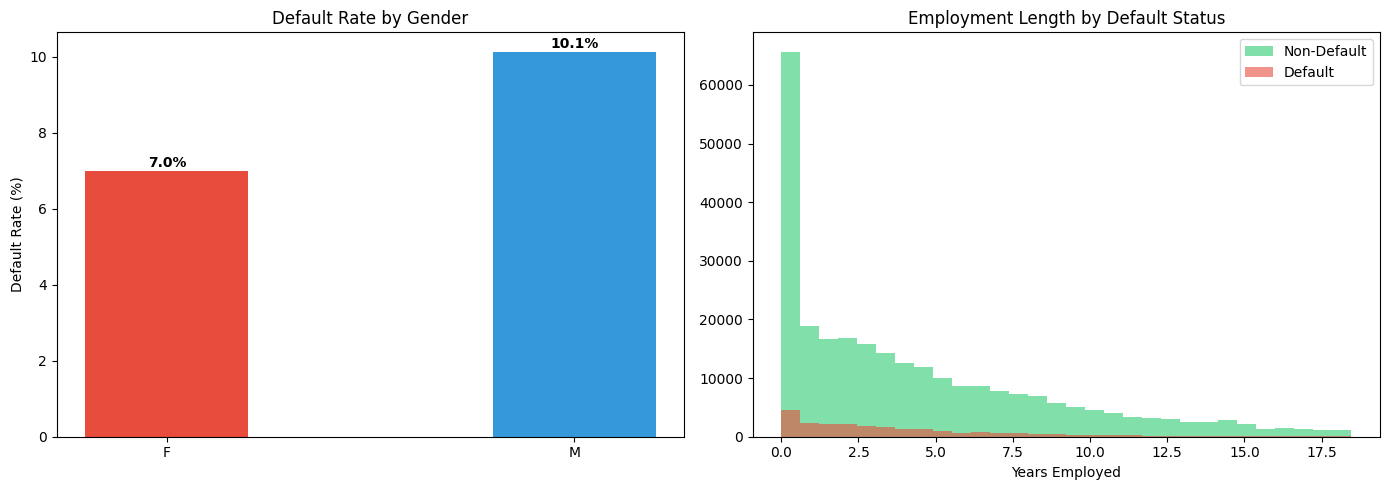

Business Insight 5: Males default more than females
Business Insight 6: Shorter employment history = higher default risk


In [22]:
# Gender and Employment Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender default rate
gender_default = df.groupby('CODE_GENDER')['TARGET'].mean() * 100
gender_default = gender_default[gender_default.index.isin(['M', 'F'])]
axes[0].bar(gender_default.index, gender_default.values,
            color=['#e74c3c', '#3498db'], width=0.4)
axes[0].set_title('Default Rate by Gender')
axes[0].set_ylabel('Default Rate (%)')
for i, v in enumerate(gender_default.values):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

# Employment length
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'].clip(upper=0) / 365)
emp_cap = df['EMPLOYMENT_YEARS'].quantile(0.95)
df_emp = df[df['EMPLOYMENT_YEARS'] <= emp_cap]
axes[1].hist(df_emp[df_emp['TARGET']==0]['EMPLOYMENT_YEARS'], bins=30, alpha=0.6, color='#2ecc71', label='Non-Default')
axes[1].hist(df_emp[df_emp['TARGET']==1]['EMPLOYMENT_YEARS'], bins=30, alpha=0.6, color='#e74c3c', label='Default')
axes[1].set_title('Employment Length by Default Status')
axes[1].set_xlabel('Years Employed')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/gender_employment_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Business Insight 5: Males default more than females")
print("Business Insight 6: Shorter employment history = higher default risk")

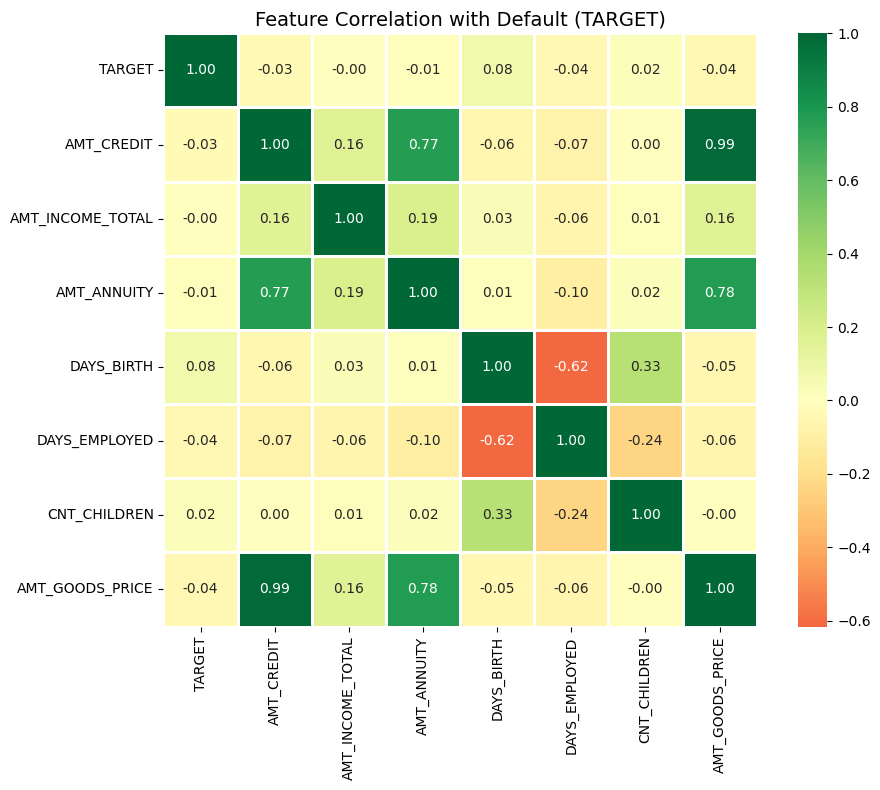

Business Insight 7: DAYS_BIRTH (age) has negative correlation with default


In [23]:
# Correlation Heatmap
key_features = ['TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 
                'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
                'CNT_CHILDREN', 'AMT_GOODS_PRICE']

corr = df[key_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation with Default (TARGET)', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/images/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("Business Insight 7: DAYS_BIRTH (age) has negative correlation with default")

Total columns with missing values: 67

Top 15 columns with most missing data:
                          Missing Count  Missing %
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_MEDI                   208642      67.85
FLOORSMIN_MODE                   208642      67.85
FLOORSMIN_AVG                    208642      67.85
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_MEDI                 204488      66.50


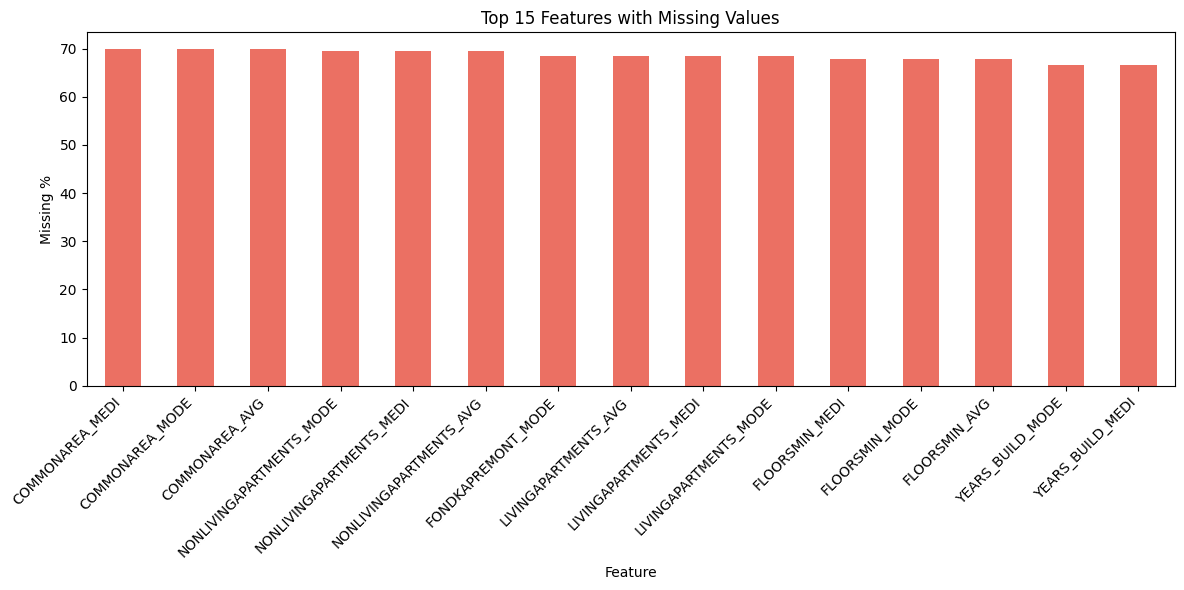

EDA Complete! All charts saved to data/ folder


In [24]:
# Data Quality Summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing, 
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Total columns with missing values: {len(missing_df)}")
print(f"\nTop 15 columns with most missing data:")
print(missing_df.head(15).to_string())

# Plot top 15
plt.figure(figsize=(12, 6))
missing_df.head(15)['Missing %'].plot(kind='bar', color='#e74c3c', alpha=0.8)
plt.title('Top 15 Features with Missing Values')
plt.xlabel('Feature')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/images/missing_values.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA Complete! All charts saved to data/ folder")